# Tutorial FigureCollection

In [73]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.miscellaneous as mi

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
rates = [['k_tS0_tS1', 7e6, "excitation", "EXC", False],  
         ['k_tS1_tS0', 1e9, "fluorescent emission", "FLU", True], 
         ['k_tS1_tT1', 1e6, "intersystem crossing ST", "ISCST", False],   
         ['k_tT1_tS0', 5e5, "intersystem crossing TS", "ISCTS", False],
         ['k_tS1_tS0', 1e9, "internal conversion S", "ICS", False],
         ['k_tS1_Cis', 2e7, "isomerization", "ISO", False],
         ['k_Cis_tS0', 1e5, "backisomerization", "BISO", False],
         ['k_tT1_OFF', 1.4e6, "reduction", "RED", False],
         ['k_OFF_tS0', 1e1, "oxidation", "OX", False]]

In [94]:
system = fs.Cy5dSTORMModel(number_fluorophores=2, distances=1, rates=rates)
system.simulate(n_steps=int(1e7), seed=100)
system.process()
system.emitters(photon_collection_rate=0.5, resample="5ms", emccd_gain=10)
system.fcs(normalize=True, log=True, m=2, deltat="10us")

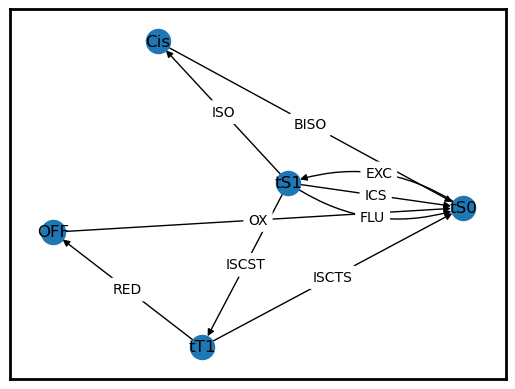

In [59]:
fig, ax = system.plot.network(10)

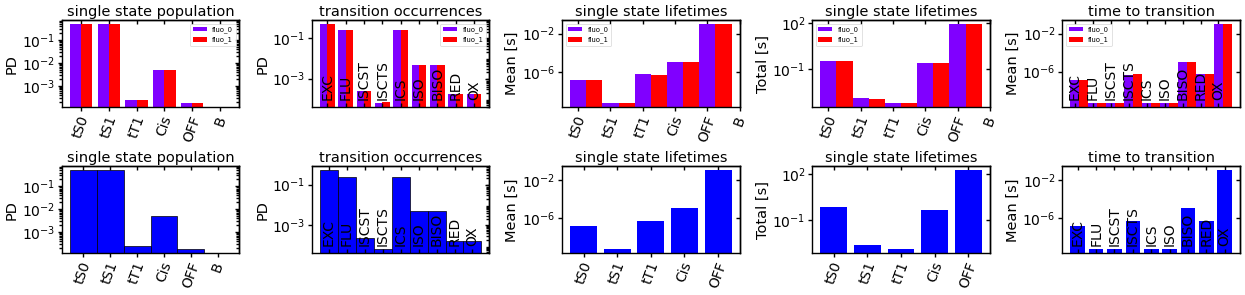

In [60]:
fig, ax = system.plot.populations(mode="single_states", single_fluorophores=True, scale=0.5, ncols=5, nrows=2, fig_width=25, fig_height=6)
_, _ = system.plot.populations(mode="single_states", single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.populations(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='mean', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.lifetimes(mode='single_states', statistic='total', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 3])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=True, scale=1, fig=fig, axes=ax[0, 4])
_, _ = system.plot.lifetimes(mode='transitions', single_fluorophores=False, scale=1, fig=fig, axes=ax[1, 4])
fig.tight_layout()

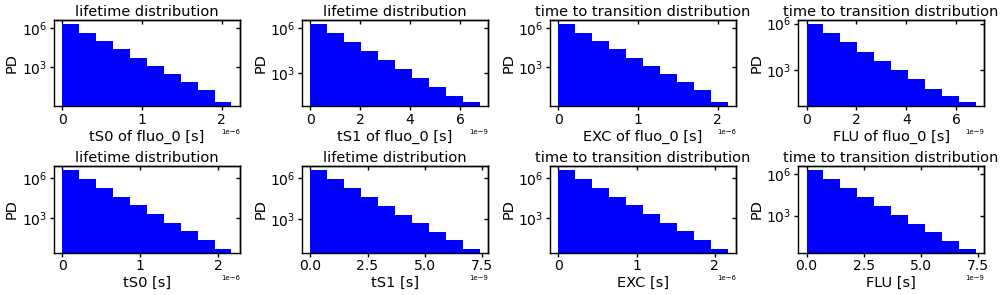

In [61]:
fig, ax = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=0, transition_id=None, scale=0.5, ncols=4, nrows=2, fig_width=20, fig_height=6)
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=0, transition_id=None, scale=1, fig=fig, axes=ax[1, 0])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=1, transition_id=None, scale=1, fig=fig, axes=ax[1, 1])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[0, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=0, scale=1, fig=fig, axes=ax[1, 2])
_, _ = system.plot.individual_lifetimes(fluorophore_id=0, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[0, 3])
_, _ = system.plot.individual_lifetimes(fluorophore_id=None, single_state_id=None, transition_id=1, scale=1, fig=fig, axes=ax[1, 3])
fig.tight_layout()

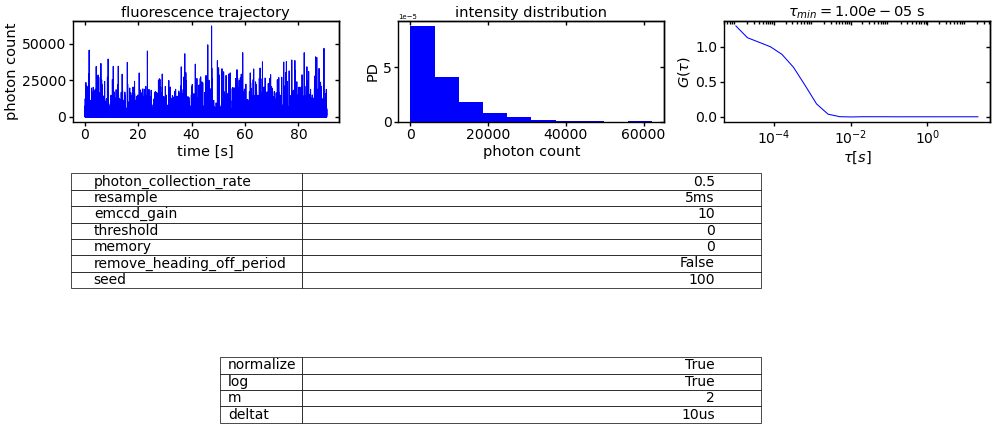

In [89]:
fig, ax = system.plot.emission_events(time_series=True, scale=0.5, ncols=3, nrows=3, fig_width=20, fig_height=9)
_, _ = system.plot.emission_events(time_series=False, scale=1, fig=fig, axes=ax[0, 1])
_, _ = system.plot.fcs(normalize_to=4, fig=fig, axes=ax[0, 2])
fig = mi.delete_subplots(fig, ax, 3)
fig = system.plot.add_table(fig, grid=312, level_0='emitters', scale=(0.5, 2), fontsize=20)
fig = system.plot.add_table(fig, grid=313, level_0='fcs', scale=(0.5, 2), fontsize=20)
fig.tight_layout()

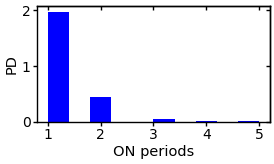

In [95]:
fig, ax = system.plot.on_off(mode='on', time_series=False, display_mean=False, scale=0.5)

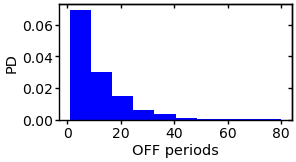

In [96]:
fig, ax = system.plot.on_off(mode='off', time_series=False, display_mean=False, scale=0.5)

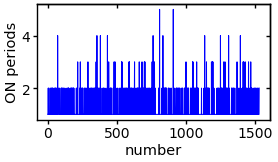

In [97]:
fig, ax = system.plot.on_off(mode='on', time_series=True, display_mean=False, scale=0.5)

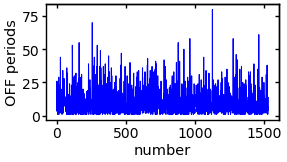

In [98]:
fig, ax = system.plot.on_off(mode='off', time_series=True, display_mean=False, scale=0.5)